# 🍌 Banana Leaf Disease Diagnosis — Evidence-Grounded VCoT Pipeline
### Grad-CAM Visual Thought + LLaVA-1.5-7B Verbal Thought

**Version 1 | PyTorch + Grad-CAM + LLaVA-1.5-7B | Google Colab A100**

---
**Pipeline:** `Image → EfficientNet-B0 Classifier → Grad-CAM Heatmap → LLaVA Open-Ended Symptom Description → Final Diagnosis`

**Classes:** `CMV` | `Healthy` | `Sigatoka`

**Dataset:** `/content/drive/MyDrive/FINAL_DATASET_CROP_MONITORING`

**VCoT (Visual Chain-of-Thought) Framing:**
Rather than a black-box label, this system externalizes a two-step reasoning trace:
1. **Visual thought** — Grad-CAM heatmap on the last conv block of EfficientNet-B0 shows *where* the classifier looked.
2. **Verbal thought** — The Grad-CAM overlay is fed into LLaVA-1.5-7B along with the classifier's prediction. LLaVA's language head then generates a free-form, open-ended symptom description grounded in the highlighted regions.

This replaces rigid rule-based templates with a true multimodal LLM description that can handle ambiguity, mixed symptoms, and novel phrasing.

---
## Notebook Structure
- **Phase 1** — Problem Formulation & Architecture Overview
- **Phase 2** — Model Choice (CNN + VLM)
- **Phase 3** — Dataset Preparation
- **Phase 4** — Training Pipeline (EfficientNet-B0)
- **Phase 5** — Explainability Module (Grad-CAM)
- **Phase 6** — LLaVA-1.5-7B Open-Ended Description Module
- **Phase 7** — End-to-End VCoT Inference Pipeline
- **Phase 8** — Evaluation & Analysis
- **Phase 9** — Research Framing & Demo

> ⚠️  **Runtime requirement:** Colab **A100 + High-RAM**. LLaVA-1.5-7B needs ~14 GB VRAM in bfloat16 on top of the EfficientNet-B0 classifier.

---
## Phase 1 — Problem Formulation

### Input / Output Contract
```
INPUT  : Single banana leaf image (JPG/PNG, any resolution)
OUTPUT : predicted_class  (str)   — CMV | Healthy | Sigatoka
         confidence       (float) — e.g. 0.934
         gradcam_heatmap  (array) — H×W float activation map
         overlay_image    (PIL)   — heatmap blended on original
         explanation      (str)   — LLaVA-generated open-ended symptom description
```

### V1 Scope
- ✅ 3-class classification with pretrained CNN (EfficientNet-B0)
- ✅ Grad-CAM visual explanation
- ✅ **LLaVA-1.5-7B open-ended symptom description** (replaces rule-based templates)
- ✅ Classifier prediction injected into LLaVA prompt → VLM is *guided* but free to describe
- ❌ No LLaVA fine-tuning in V1 — we use zero-shot on the classifier's overlay

### Why "Visual Chain-of-Thought"?
MVoT (Li et al., 2025) argues models should *externalize* reasoning through visual + verbal thoughts. Here:
- **Visual thought** = Grad-CAM heatmap on EfficientNet's last conv block. A spatial saliency map over the leaf surface.
- **Verbal thought** = LLaVA's open-ended description of the highlighted regions, conditioned on the classifier's prediction. Produced by LLaVA's autoregressive language head.

The pipeline is **evidence-grounded**: LLaVA does not speak in a vacuum — it literally looks at the region the classifier found important, and the classifier's prediction anchors the description to one of three disease hypotheses.

---
## Phase 2 — Model Choice

### Classifier — EfficientNet-B0

| Model | Params | Top-1 (ImageNet) | Colab A100 Speed | Grad-CAM Support |
|---|---|---|---|---|
| ResNet-18 | 11M | 69.8% | Very fast | ✅ layer4 |
| MobileNetV3-Large | 5.4M | 75.3% | Fastest | ⚠️ tricky last conv |
| **EfficientNet-B0** | **5.3M** | **77.1%** | **Fast** | **✅ features[-1]** |

**Pick: EfficientNet-B0** — best accuracy-to-size ratio for leaf texture, clean Grad-CAM target layer.

### Vision-Language Model — LLaVA-1.5-7B

| Model | VLM Params | A100 VRAM (bf16) | Visual Reasoning |
|---|---|---|---|
| BLIP-2 OPT-2.7B | 2.7B | ~6 GB | Captioning, weaker reasoning |
| InstructBLIP | 3B | ~8 GB | Better instructions |
| **LLaVA-1.5-7B** | **7B** | **~14 GB** | **Strong instruction-following, best open-ended description quality** |

**Pick: LLaVA-1.5-7B** — the language head is instruction-tuned on visual reasoning data, giving coherent, grounded descriptions when shown a Grad-CAM overlay and told what the classifier predicted.

---
## Setup — Install Dependencies

In [1]:
# ── CNN + Grad-CAM deps ──
!pip install -q grad-cam==1.5.0 torchmetrics matplotlib seaborn scikit-learn Pillow
print('✅ Classifier deps installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 6.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.1 MB/s eta 0:00:00
✅ Classifier deps installed


In [2]:
# ── LLaVA-1.5-7B deps (pinned versions — LLaVA is sensitive to transformers/tokenizers combo) ──
!pip install -q "transformers==4.40.0" "tokenizers==0.19.1" "accelerate==0.30.0"
# Tokenizer version pin must be reinforced because other pip installs silently upgrade it.
!pip install -q --force-reinstall --no-deps "tokenizers==0.19.1"
print('✅ LLaVA deps installed — if prompted, Runtime → Restart session, then re-run from this cell onward')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 129.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.4/302.4 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ LLaVA deps installed — if prompted, Runtime → Restart session, then re-run from this cell onward


In [3]:
import tokenizers, transformers
print(f'tokenizers  : {tokenizers.__version__}  (must be 0.19.1)')
print(f'transformers: {transformers.__version__}  (must be 4.40.0)')

tokenizers  : 0.19.1  (must be 0.19.1)
transformers: 4.40.0  (must be 4.40.0)


In [4]:
# ── Runtime check — LLaVA-1.5-7B needs A100 + High-RAM ──
import subprocess, psutil, torch
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout.split('\n')[7:10])
print(f'System RAM : {psutil.virtual_memory().total / 1e9:.1f} GB')
print(f'CUDA       : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU        : {torch.cuda.get_device_name(0)}')
    print(f'VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

['|=========================================+========================+======================|', '|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |', '| N/A   30C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |']
System RAM : 89.6 GB
CUDA       : True
GPU        : NVIDIA A100-SXM4-40GB
VRAM       : 42.4 GB


In [5]:
# ── Core imports ──────────────────────────────────────────────────────────────
import os
import json
import random
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from datetime import datetime

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from torchmetrics import Accuracy, Precision, Recall, F1Score

# ── Grad-CAM ──────────────────────────────────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ── LLaVA (loaded later in Phase 6 — imports deferred for clarity) ────────────
# from transformers import LlavaProcessor, LlamaTokenizer, CLIPImageProcessor, LlavaForConditionalGeneration

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Device: cuda
   GPU : NVIDIA A100-SXM4-40GB
   VRAM: 42.4 GB


---
## Phase 3 — Dataset Preparation

In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  EDIT THIS SECTION — Paths & Hyperparameters               ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Dataset root ──────────────────────────────────────────────
# Expected folder structure (auto-detected via keywords):
#   DATASET_ROOT/CMV/          or any folder whose name contains 'cmv'
#   DATASET_ROOT/HEALTHY/      or any folder whose name contains 'healthy'
#   DATASET_ROOT/SIGATOKA/     or any folder whose name contains 'sigatoka'
DATASET_ROOT = '/content/drive/MyDrive/FINAL_DATASET_CROP_MONITORING'

# ── Split directory (auto-created) ────────────────────────────
SPLIT_ROOT   = '/content/banana_split'

# ── Model checkpoint save path ────────────────────────────────
CHECKPOINT_PATH = '/content/best_model_banana.pth'

# ── LLaVA model ID ────────────────────────────────────────────
LLAVA_MODEL_ID = 'llava-hf/llava-1.5-7b-hf'

# ── Class names (sorted alphabetically to match ImageFolder) ──
# NOTE: folder names are auto-detected by keyword ('cmv', 'healthy', 'sigatoka')
# but the canonical class list is these three strings, sorted.
CLASS_NAMES = ['CMV', 'Healthy', 'Sigatoka']
NUM_CLASSES = len(CLASS_NAMES)

# Keyword → canonical label (used when copying into SPLIT_ROOT)
CLASS_KEYWORDS = {
    'cmv':      'CMV',
    'healthy':  'Healthy',
    'sigatoka': 'Sigatoka',
}

# Per-class color for plots (consistent across the notebook)
CLASS_COLORS = {
    'CMV':      'purple',
    'Healthy':  'green',
    'Sigatoka': 'orange',
}

# ── Hyperparameters (tuned for Colab A100) ────────────────────
IMAGE_SIZE      = 224     # EfficientNet-B0 native size
BATCH_SIZE      = 32      # A100 has plenty of VRAM
NUM_EPOCHS      = 30
LR              = 3e-4
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTHING = 0.1

# ── Train / Val / Test splits ─────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# ── LLaVA generation settings ─────────────────────────────────
LLAVA_MAX_NEW_TOKENS = 140    # ~3 sentences
LLAVA_TEMPERATURE    = 0       # deterministic
LLAVA_DO_SAMPLE      = False

print('✅ Config loaded')
print(f'   Dataset: {DATASET_ROOT}')
print(f'   Classes: {CLASS_NAMES}')
print(f'   Image size: {IMAGE_SIZE}px | Batch: {BATCH_SIZE} | Epochs: {NUM_EPOCHS}')
print(f'   LLaVA: {LLAVA_MODEL_ID}')

✅ Config loaded
   Dataset: /content/drive/MyDrive/FINAL_DATASET_CROP_MONITORING
   Classes: ['CMV', 'Healthy', 'Sigatoka']
   Image size: 224px | Batch: 32 | Epochs: 30
   LLaVA: llava-hf/llava-1.5-7b-hf


In [7]:
# Mount Google Drive (only needed in Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('✅ Drive mounted')
except ImportError:
    print('ℹ️  Not in Colab — skipping drive mount')

Mounted at /content/drive
✅ Drive mounted


In [8]:
# ── Verify dataset structure (keyword-based folder detection) ─────────────────
def detect_class_from_folder(folder_name: str):
    '''Return canonical class name if folder matches a known keyword, else None.'''
    fl = folder_name.lower()
    for kw, cls in CLASS_KEYWORDS.items():
        if kw in fl:
            return cls
    return None


def verify_dataset(root: str, class_names: list) -> dict:
    '''Check dataset exists, count images per canonical class, flag issues.'''
    root = Path(root)
    assert root.exists(), f'❌ Dataset root not found: {root}\n   → Edit DATASET_ROOT in the config cell'

    stats = {cls: 0 for cls in class_names}
    folder_map = {}  # canonical_class → [folder paths]

    print(f'\nDataset: {root}')
    print('-' * 60)

    for folder in sorted(root.iterdir()):
        if not folder.is_dir():
            continue
        canon = detect_class_from_folder(folder.name)
        if canon is None:
            print(f'  ⚠️  Unrecognised folder (skipped): {folder.name}')
            continue
        imgs = list(folder.glob('*.[jJpP][pPnN][gG]*'))
        stats[canon] += len(imgs)
        folder_map.setdefault(canon, []).append(folder)
        print(f'  {folder.name:45s} → {canon:22s} ({len(imgs)} images)')

    print('-' * 60)
    for cls in class_names:
        print(f'  {cls:22s}: {stats[cls]:>5d} images')
    total = sum(stats.values())
    print(f'  {"TOTAL":22s}: {total:>5d} images')

    # Imbalance check
    counts = [v for v in stats.values() if v > 0]
    if counts:
        ratio = max(counts) / max(min(counts), 1)
        if ratio > 3:
            print(f'\n⚠️  Imbalance ratio {ratio:.1f}x → WeightedRandomSampler will be applied')
        else:
            print(f'\n✅ Class balance ratio: {ratio:.1f}x (acceptable)')
    return stats, folder_map


class_counts, folder_map = verify_dataset(DATASET_ROOT, CLASS_NAMES)


Dataset: /content/drive/MyDrive/FINAL_DATASET_CROP_MONITORING
------------------------------------------------------------
  CMV                                           → CMV                    (1048 images)
  HEALTHY                                       → Healthy                (938 images)
  SIGATOKA                                      → Sigatoka               (1037 images)
------------------------------------------------------------
  CMV                   :  1048 images
  Healthy               :   938 images
  Sigatoka              :  1037 images
  TOTAL                 :  3023 images

✅ Class balance ratio: 1.1x (acceptable)


In [9]:
# ── Train / Val / Test split ──────────────────────────────────────────────────
# Copies images from the original dataset folders into a clean
# SPLIT_ROOT/{train,val,test}/{canonical_class}/ structure.

def create_splits(folder_map: dict, dst_root: str, class_names: list,
                  train_r=0.70, val_r=0.15, seed=42):
    '''Split images into train/val/test and copy into canonical class folders.'''
    dst_root = Path(dst_root)

    if (dst_root / 'train').exists():
        print('✅ Splits already exist — skipping')
        return

    random.seed(seed)
    splits = {'train': train_r, 'val': val_r, 'test': 1 - train_r - val_r}

    for split in splits:
        for cls in class_names:
            (dst_root / split / cls).mkdir(parents=True, exist_ok=True)

    split_stats = {s: {c: 0 for c in class_names} for s in splits}

    for cls in class_names:
        imgs = []
        for folder in folder_map.get(cls, []):
            imgs.extend(sorted(folder.glob('*.[jJpP][pPnN][gG]*')))
        random.shuffle(imgs)

        n       = len(imgs)
        n_train = int(n * train_r)
        n_val   = int(n * val_r)

        assign = (
            [('train', img) for img in imgs[:n_train]] +
            [('val',   img) for img in imgs[n_train:n_train + n_val]] +
            [('test',  img) for img in imgs[n_train + n_val:]]
        )

        for split_name, img_path in assign:
            dst = dst_root / split_name / cls / img_path.name
            shutil.copy2(img_path, dst)
            split_stats[split_name][cls] += 1

    print('\n✅ Dataset split complete:')
    print(f'{"":10s}', end='')
    for cls in class_names:
        print(f'{cls:>22s}', end='')
    print()
    for split_name, counts in split_stats.items():
        print(f'{split_name:10s}', end='')
        for cls in class_names:
            print(f'{counts[cls]:>22d}', end='')
        print()


create_splits(folder_map, SPLIT_ROOT, CLASS_NAMES,
              train_r=TRAIN_RATIO, val_r=VAL_RATIO)


✅ Dataset split complete:
                             CMV               Healthy              Sigatoka
train                        733                   656                   725
val                          157                   140                   155
test                         158                   142                   157


In [10]:
# ── Transforms & Augmentation ─────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('✅ Transforms defined')
print('   Train aug: Crop, Flip, ColorJitter, Rotation, Affine')
print('   Val/Test : Resize + Normalize only (no aug)')

✅ Transforms defined
   Train aug: Crop, Flip, ColorJitter, Rotation, Affine
   Val/Test : Resize + Normalize only (no aug)


In [11]:
# ── Datasets & DataLoaders ────────────────────────────────────────────────────
train_dataset = datasets.ImageFolder(os.path.join(SPLIT_ROOT, 'train'), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(SPLIT_ROOT, 'val'),   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(SPLIT_ROOT, 'test'),  transform=val_test_transform)

IDX_TO_CLASS = {v: k for k, v in train_dataset.class_to_idx.items()}
print(f'Class → Index mapping: {train_dataset.class_to_idx}')

# ── WeightedRandomSampler for class imbalance ────────────────────────────────
targets = [s[1] for s in train_dataset.samples]
class_counts_train = Counter(targets)
class_weights = {cls: 1.0 / count for cls, count in class_counts_train.items()}
sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'\n✅ DataLoaders ready')
print(f'   Train: {len(train_dataset)} images | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Class → Index mapping: {'CMV': 0, 'Healthy': 1, 'Sigatoka': 2}

✅ DataLoaders ready
   Train: 2114 images | Val: 452 | Test: 457


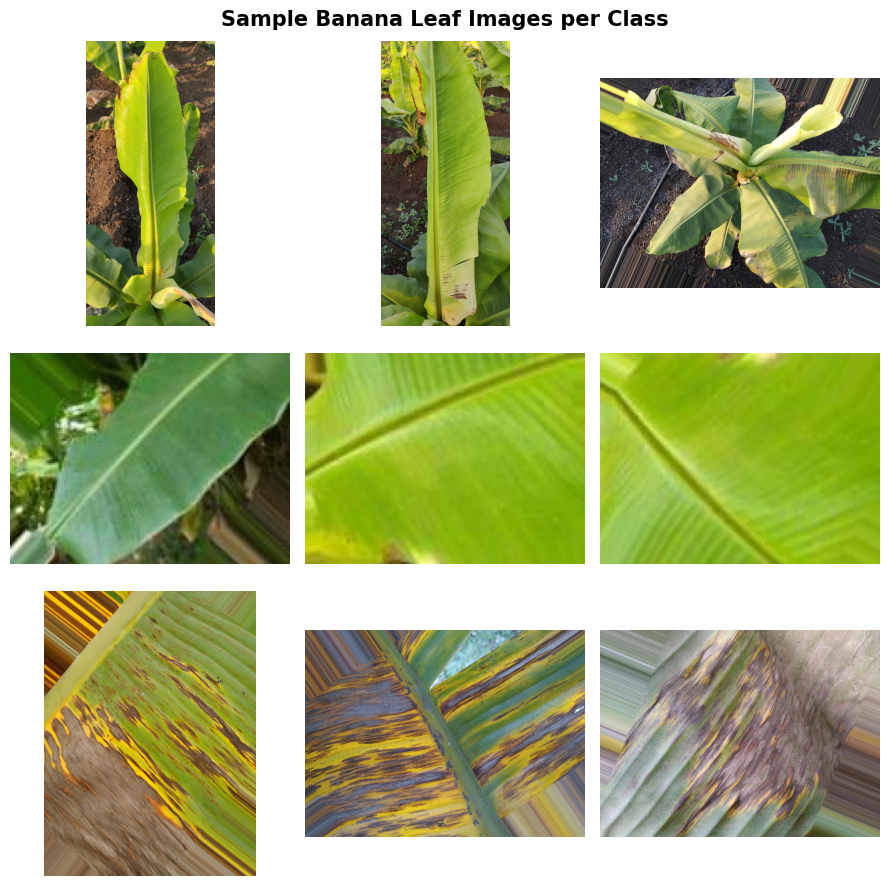

✅ Sample images saved to /content/banana_sample_images.png


In [12]:
# ── Visualize sample images from each class ──────────────────────────────────
def show_samples(dataset, class_names, n_per_class=3):
    fig, axes = plt.subplots(len(class_names), n_per_class,
                              figsize=(n_per_class * 3, len(class_names) * 3))
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

    class_samples = {cls: [] for cls in class_names}
    for path, label in dataset.samples:
        cls = idx_to_class[label]
        if len(class_samples[cls]) < n_per_class:
            class_samples[cls].append(path)

    for row, cls in enumerate(class_names):
        for col, img_path in enumerate(class_samples[cls]):
            img = Image.open(img_path).convert('RGB')
            ax = axes[row][col]
            ax.imshow(img)
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(cls, fontsize=12, fontweight='bold', rotation=90, labelpad=10)

    plt.suptitle('Sample Banana Leaf Images per Class', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/banana_sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Sample images saved to /content/banana_sample_images.png')


show_samples(train_dataset, CLASS_NAMES)

---
## Phase 4 — Training Pipeline

In [13]:
# ── Build EfficientNet-B0 classifier ─────────────────────────────────────────
def build_model(num_classes: int, pretrained: bool = True) -> nn.Module:
    '''
    EfficientNet-B0 fine-tuned for banana leaf disease classification.
    Strategy:
      - Load ImageNet pretrained weights
      - Replace final classifier head for our 3 classes (CMV / Healthy / Sigatoka)
      - Unfreeze ALL layers (full fine-tune)
    '''
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.efficientnet_b0(weights=weights)

    # Replace classifier head: Linear(1280, 1000) → Dropout + Linear(1280, 3)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model


model = build_model(NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ EfficientNet-B0 built')
print(f'   Total params  : {total_params:,}')
print(f'   Trainable     : {train_params:,}')
print(f'   Grad-CAM layer: model.features[-1]')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 206MB/s]


✅ EfficientNet-B0 built
   Total params  : 4,011,391
   Trainable     : 4,011,391
   Grad-CAM layer: model.features[-1]


In [14]:
# ── Loss, Optimizer, Scheduler ────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
# Label smoothing reduces overconfidence — helpful when CMV and Sigatoka
# may produce overlapping leaf discoloration patterns.

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f'✅ Loss: CrossEntropy (label_smoothing={LABEL_SMOOTHING})')
print(f'   Optimizer: AdamW (lr={LR}, wd={WEIGHT_DECAY})')
print(f'   Scheduler: CosineAnnealing (T_max={NUM_EPOCHS})')

✅ Loss: CrossEntropy (label_smoothing=0.1)
   Optimizer: AdamW (lr=0.0003, wd=0.0001)
   Scheduler: CosineAnnealing (T_max=30)


In [15]:
# ── Training & Validation loops ───────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, correct / total, f1


print('✅ Training functions defined')

✅ Training functions defined


In [16]:
# ── Main Training Loop ────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [],
           'val_loss':   [], 'val_acc':   [], 'val_f1': []}

best_val_f1 = 0.0
best_epoch  = 0

print(f'Starting training for {NUM_EPOCHS} epochs on {DEVICE}\n')
print(f'{"Epoch":>6} {"Train Loss":>12} {"Train Acc":>11} {"Val Loss":>10} {"Val Acc":>9} {"Val F1":>8} {"LR":>10}')
print('-' * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    flag = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_f1': val_f1,
                    'val_acc': val_acc,
                    'class_to_idx': train_dataset.class_to_idx},
                   CHECKPOINT_PATH)
        flag = ' ✅ saved'

    print(f'{epoch:>6d} {train_loss:>12.4f} {train_acc:>10.4f} '
          f'{val_loss:>10.4f} {val_acc:>9.4f} {val_f1:>8.4f} '
          f'{current_lr:>10.2e}{flag}')

print(f'\n🏆 Best model: Epoch {best_epoch} | Val F1: {best_val_f1:.4f}')
print(f'   Saved to: {CHECKPOINT_PATH}')

Starting training for 30 epochs on cuda

 Epoch   Train Loss   Train Acc   Val Loss   Val Acc   Val F1         LR
------------------------------------------------------------------------
     1       0.4276     0.9480     0.3183    1.0000   1.0000   2.99e-04 ✅ saved
     2       0.3321     0.9863     0.3071    0.9956   0.9956   2.97e-04
     3       0.3197     0.9924     0.3046    0.9978   0.9977   2.93e-04
     4       0.3094     0.9953     0.3008    1.0000   1.0000   2.87e-04
     5       0.3113     0.9948     0.2971    1.0000   1.0000   2.80e-04
     6       0.3035     0.9986     0.2950    1.0000   1.0000   2.71e-04
     7       0.3031     0.9962     0.2968    1.0000   1.0000   2.62e-04
     8       0.3030     0.9967     0.2946    1.0000   1.0000   2.51e-04
     9       0.3009     0.9981     0.2950    1.0000   1.0000   2.38e-04
    10       0.2988     0.9991     0.2938    1.0000   1.0000   2.25e-04
    11       0.2987     0.9986     0.2940    1.0000   1.0000   2.11e-04
    12       

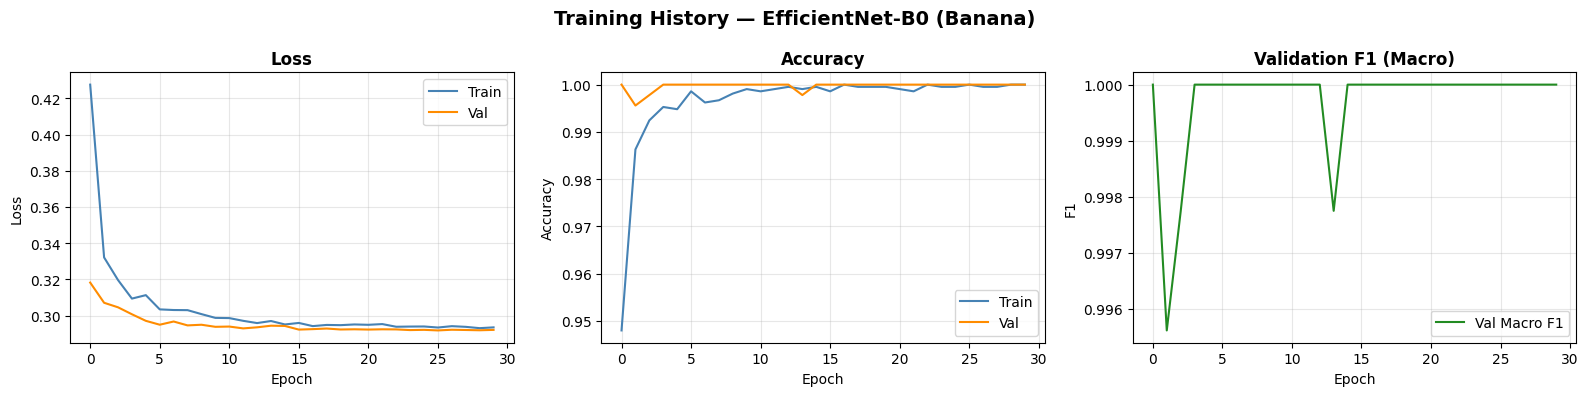

In [17]:
# ── Plot Training History ─────────────────────────────────────────────────────
def plot_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(history['train_loss'], label='Train', color='steelblue')
    axes[0].plot(history['val_loss'],   label='Val',   color='darkorange')
    axes[0].set_title('Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train', color='steelblue')
    axes[1].plot(history['val_acc'],   label='Val',   color='darkorange')
    axes[1].set_title('Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(history['val_f1'], label='Val Macro F1', color='forestgreen')
    axes[2].set_title('Validation F1 (Macro)', fontweight='bold')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1')
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle('Training History — EfficientNet-B0 (Banana)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/banana_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_history(history)

---
## Phase 5 — Explainability Module (Grad-CAM)

In [18]:
# ── Load best model for inference ─────────────────────────────────────────────
def load_best_model(checkpoint_path: str, num_classes: int, device) -> nn.Module:
    model = build_model(num_classes, pretrained=False)
    ckpt  = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(device)
    model.eval()
    print(f'✅ Loaded model from epoch {ckpt["epoch"]} | Val F1: {ckpt["val_f1"]:.4f}')
    return model


best_model = load_best_model(CHECKPOINT_PATH, NUM_CLASSES, DEVICE)

# ── Grad-CAM setup ────────────────────────────────────────────────────────────
# Target layer: model.features[-1]
# WHY: last conv block (MBConv9) — richest semantic feature maps with good spatial res.
# For banana leaves, this captures mosaic patches (CMV), streak/yellowing (Sigatoka),
# and uniform green (Healthy).
TARGET_LAYER = [best_model.features[-1]]

gradcam = GradCAM(model=best_model, target_layers=TARGET_LAYER)
print(f'✅ Grad-CAM initialized on: model.features[-1]')

✅ Loaded model from epoch 1 | Val F1: 1.0000
✅ Grad-CAM initialized on: model.features[-1]


In [19]:
# ── Grad-CAM utility functions ────────────────────────────────────────────────

def preprocess_image(image_path: str) -> tuple:
    '''
    Load image and return:
      - rgb_float : H×W×3 float32 in [0,1] for overlay
      - tensor    : 1×3×H×W normalized tensor for model
      - pil_img   : original PIL image
    '''
    pil_img  = Image.open(image_path).convert('RGB')
    pil_resized = pil_img.resize((IMAGE_SIZE, IMAGE_SIZE))
    rgb_float = np.array(pil_resized).astype(np.float32) / 255.0

    tensor = val_test_transform(pil_resized).unsqueeze(0).to(DEVICE)
    return rgb_float, tensor, pil_img


def compute_gradcam(gradcam_obj, tensor: torch.Tensor, class_idx: int) -> np.ndarray:
    '''Compute Grad-CAM heatmap for a given class index. Returns H×W float in [0, 1].'''
    targets = [ClassifierOutputTarget(class_idx)]
    heatmap = gradcam_obj(input_tensor=tensor, targets=targets)
    return heatmap[0]


def overlay_heatmap(rgb_float: np.ndarray, heatmap: np.ndarray,
                    alpha: float = 0.5) -> np.ndarray:
    '''Blend Grad-CAM heatmap onto original image. Returns H×W×3 uint8.'''
    overlay = show_cam_on_image(rgb_float, heatmap, use_rgb=True)
    return overlay


def extract_heatmap_stats(heatmap: np.ndarray, threshold: float = 0.5) -> dict:
    '''
    Extract statistics from Grad-CAM heatmap.
    Used both for analysis AND as text features injected into the LLaVA prompt.
      - coverage      : % of image area above threshold
      - peak_location : which quadrant has the highest activation
      - mean_intensity: average activation value
      - top_20_mean   : mean of top-20% activations (spread indicator)
    '''
    h, w = heatmap.shape

    coverage = float((heatmap > threshold).sum()) / (h * w)

    peak_y, peak_x = np.unravel_index(heatmap.argmax(), heatmap.shape)
    vert  = 'upper' if peak_y < h / 2 else 'lower'
    horiz = 'left'  if peak_x < w / 2 else 'right'
    peak_location = f'{vert}-{horiz}'

    top_20_mean = float(np.sort(heatmap.ravel())[-int(0.2 * h * w):].mean())

    return {
        'coverage':       coverage,
        'peak_location':  peak_location,
        'mean_intensity': float(heatmap.mean()),
        'top_20_mean':    top_20_mean,
    }


print('✅ Grad-CAM utility functions defined')

✅ Grad-CAM utility functions defined


---
## Phase 6 — LLaVA-1.5-7B Open-Ended Symptom Description

**This is the core change from the rule-based V0.**

Instead of selecting one of fixed templates based on heatmap coverage, we let LLaVA-1.5-7B's language head generate a free-form description. The VLM is given:
1. **The Grad-CAM overlay image** as visual input — so it sees the leaf *and* where the classifier attended.
2. **A text prompt** that states the classifier's predicted class, confidence, and heatmap statistics (coverage, peak region) — grounding the description in the classifier's evidence.

This gives a *true* multimodal reasoning trace: visual (Grad-CAM) + verbal (LLaVA) thoughts, produced by an instruction-tuned LLM rather than hand-written templates.

In [20]:
# ── Load LLaVA-1.5-7B ────────────────────────────────────────────────────────
from transformers import LlavaProcessor, LlamaTokenizer, CLIPImageProcessor, LlavaForConditionalGeneration

print(f'Loading {LLAVA_MODEL_ID} — this takes 2-3 minutes on A100...')

# Build the processor manually — avoids auto-processor fast-tokenizer issues on LLaVA-1.5
llava_tokenizer       = LlamaTokenizer.from_pretrained(LLAVA_MODEL_ID, use_fast=False)
llava_image_processor = CLIPImageProcessor.from_pretrained(LLAVA_MODEL_ID)
llava_processor       = LlavaProcessor(image_processor=llava_image_processor,
                                       tokenizer=llava_tokenizer)

llava_model = LlavaForConditionalGeneration.from_pretrained(
    LLAVA_MODEL_ID,
    torch_dtype=torch.bfloat16,   # A100 native bf16 → fast + memory-efficient
    device_map='auto',
    low_cpu_mem_usage=True
)
llava_model.eval()

llava_params = sum(p.numel() for p in llava_model.parameters())
print(f'\n✅ LLaVA loaded')
print(f'   Params    : {llava_params/1e9:.2f}B')
print(f'   VRAM used : {torch.cuda.memory_allocated()/1e9:.2f} GB')
print(f'   Dtype     : bfloat16')

Loading llava-hf/llava-1.5-7b-hf — this takes 2-3 minutes on A100...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


✅ LLaVA loaded
   Params    : 7.06B
   VRAM used : 14.30 GB
   Dtype     : bfloat16


In [21]:
# ── Class-specific symptom anchors (injected into LLaVA prompt for grounding) ─
# These anchors don't dictate the output — they just give LLaVA the plant
# pathology context it needs to describe symptoms using the right terminology.

CLASS_SYMPTOM_ANCHORS = {
    'Healthy': (
        'A healthy banana leaf is uniformly deep green with a smooth, waxy surface, '
        'intact margins, and no spots, streaks, yellowing, mosaic patterns, or lesions.'
    ),
    'CMV': (
        'Cucumber Mosaic Virus (CMV) on banana produces a characteristic mosaic pattern: '
        'irregular light-green to yellow-green patches interspersed with darker green areas, '
        'often with leaf distortion, chlorotic streaking along the midrib and veins, '
        'and possible leaf narrowing or rugosity.'
    ),
    'Sigatoka': (
        'Sigatoka (Black Sigatoka / Yellow Sigatoka — Mycosphaerella spp.) on banana '
        'produces elongated pale-yellow to brown streaks initially parallel to the veins, '
        'which enlarge into dark-brown to black necrotic lesions with yellowish halos. '
        'Severe infections lead to large dead leaf areas and premature leaf death.'
    ),
}


def build_llava_prompt(predicted_class: str,
                       confidence: float,
                       heatmap_stats: dict) -> str:
    '''
    Construct the text half of the VCoT prompt.
    LLaVA receives: (Grad-CAM overlay image) + (this text prompt).
    '''
    coverage_pct = heatmap_stats['coverage'] * 100
    peak         = heatmap_stats['peak_location']
    anchor       = CLASS_SYMPTOM_ANCHORS[predicted_class]

    prompt = (
        f"You are a plant pathology expert examining a banana leaf.\n\n"
        f"A disease classifier (EfficientNet-B0) has analyzed this leaf and predicts: "
        f"{predicted_class} (confidence: {confidence:.1%}).\n\n"
        f"The image you see has a Grad-CAM heatmap overlay — the red/yellow regions "
        f"highlight where the classifier focused its attention, indicating the regions "
        f"it considers most diagnostic. "
        f"Attention coverage: {coverage_pct:.0f}% of the leaf area. "
        f"Peak attention: {peak} quadrant.\n\n"
        f"For reference on this disease class: {anchor}\n\n"
        f"TASK: In 2-3 sentences, describe the actual visible symptoms in the "
        f"highlighted regions of THIS leaf. Be specific about color patterns, mosaic texture, "
        f"streak distribution, necrosis, halos, or vein-parallel patterns. Do not just repeat "
        f"the reference — describe what you see. If the visible symptoms do not match the "
        f"predicted class well, say so."
    )
    return prompt


# Show an example prompt
print('Example LLaVA prompt for Sigatoka prediction (conf=0.88, coverage=29%):\n')
example_stats = {'coverage': 0.29, 'peak_location': 'lower-right'}
print(build_llava_prompt('Sigatoka', 0.88, example_stats))

Example LLaVA prompt for Sigatoka prediction (conf=0.88, coverage=29%):

You are a plant pathology expert examining a banana leaf.

A disease classifier (EfficientNet-B0) has analyzed this leaf and predicts: Sigatoka (confidence: 88.0%).

The image you see has a Grad-CAM heatmap overlay — the red/yellow regions highlight where the classifier focused its attention, indicating the regions it considers most diagnostic. Attention coverage: 29% of the leaf area. Peak attention: lower-right quadrant.

For reference on this disease class: Sigatoka (Black Sigatoka / Yellow Sigatoka — Mycosphaerella spp.) on banana produces elongated pale-yellow to brown streaks initially parallel to the veins, which enlarge into dark-brown to black necrotic lesions with yellowish halos. Severe infections lead to large dead leaf areas and premature leaf death.

TASK: In 2-3 sentences, describe the actual visible symptoms in the highlighted regions of THIS leaf. Be specific about color patterns, mosaic texture, 

In [22]:
# ── LLaVA inference function ──────────────────────────────────────────────────

@torch.inference_mode()
def llava_describe(overlay_image,
                   predicted_class: str,
                   confidence: float,
                   heatmap_stats: dict,
                   max_new_tokens: int = LLAVA_MAX_NEW_TOKENS) -> str:
    '''
    Run LLaVA-1.5-7B on the Grad-CAM overlay with a VCoT-style prompt.

    Args:
        overlay_image   : np.ndarray H×W×3 uint8 OR PIL.Image.Image
        predicted_class : classifier's top prediction
        confidence      : classifier's softmax probability for that class
        heatmap_stats   : dict from extract_heatmap_stats()

    Returns:
        A 2-3 sentence open-ended description generated by LLaVA's language head.
    '''
    # Accept either numpy or PIL
    if isinstance(overlay_image, np.ndarray):
        pil_overlay = Image.fromarray(overlay_image).convert('RGB')
    else:
        pil_overlay = overlay_image.convert('RGB')

    text_prompt   = build_llava_prompt(predicted_class, confidence, heatmap_stats)
    # LLaVA-1.5 native chat format
    formatted     = f"USER: <image>\n{text_prompt}\nASSISTANT:"

    inputs = llava_processor(
        images=pil_overlay,
        text=formatted,
        return_tensors='pt'
    ).to(DEVICE, torch.bfloat16)

    output_ids = llava_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=LLAVA_DO_SAMPLE,
        temperature=None,
        top_p=None,
    )

    input_len     = inputs['input_ids'].shape[1]
    generated_ids = output_ids[:, input_len:]
    response      = llava_processor.batch_decode(generated_ids,
                                                  skip_special_tokens=True)[0]
    return response.strip()


print('✅ llava_describe() ready')

✅ llava_describe() ready


In [23]:
# ── Quick smoke test of LLaVA description on a test image ────────────────────
# This verifies the full visual-thought → verbal-thought chain works end-to-end.

_test_img = next(Path(SPLIT_ROOT).rglob('test/**/*.[jJpP][pPnN][gG]*'), None)
if _test_img is not None:
    _rgb, _tensor, _ = preprocess_image(str(_test_img))
    with torch.no_grad():
        _probs = F.softmax(best_model(_tensor), dim=1)[0]
    _idx   = _probs.argmax().item()
    _cls   = CLASS_NAMES[_idx]
    _conf  = _probs[_idx].item()
    _hm    = compute_gradcam(gradcam, _tensor, _idx)
    _over  = overlay_heatmap(_rgb, _hm)
    _stats = extract_heatmap_stats(_hm)

    print(f'Test image : {_test_img.name}')
    print(f'True class : {_test_img.parent.name}')
    print(f'Predicted  : {_cls} ({_conf:.1%})')
    print(f'Coverage   : {_stats["coverage"]:.1%} | Peak: {_stats["peak_location"]}')
    print('\n--- LLaVA description ---')
    _desc = llava_describe(_over, _cls, _conf, _stats)
    print(_desc)
else:
    print('⚠️  No test image found for smoke test')

Test image : cmv89.jpg
True class : CMV
Predicted  : CMV (84.0%)
Coverage   : 37.9% | Peak: lower-right

--- LLaVA description ---
The leaf exhibits a mosaic pattern with irregular light-green to yellow-green patches interspersed with darker green areas. The pattern is characterized by leaf distortion, chlorotic streaking along the midrib and veins, and possible leaf narrowing or rugosity. The attention of the classifier is focused on the lower-right quadrant of the leaf.


---
## Phase 7 — End-to-End VCoT Inference Pipeline

In [24]:
# ── End-to-End VCoT Pipeline ─────────────────────────────────────────────────

def diagnose_leaf(image_path: str,
                  model: nn.Module,
                  gradcam_obj,
                  class_names: list,
                  device,
                  use_llava: bool = True,
                  save_dir: str = None) -> dict:
    '''
    Full VCoT pipeline:
        image
          → EfficientNet classification (label + confidence)
          → Grad-CAM heatmap (visual thought)
          → LLaVA open-ended description (verbal thought)
          → structured diagnosis dict

    Args:
        image_path  : path to input banana leaf image
        model       : trained EfficientNet-B0
        gradcam_obj : initialized GradCAM object
        class_names : list of class strings (CMV / Healthy / Sigatoka)
        device      : torch device
        use_llava   : if False, skip LLaVA (useful for fast batch eval)
        save_dir    : if provided, saves overlay image here

    Returns:
        dict with: predicted_class, confidence, all_probs,
                   heatmap, overlay, heatmap_stats, explanation (LLaVA)
    '''
    model.eval()

    # Step 1: Preprocess
    rgb_float, tensor, pil_img = preprocess_image(image_path)

    # Step 2: Classification
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1)[0]

    pred_idx   = probs.argmax().item()
    confidence = probs[pred_idx].item()
    pred_class = class_names[pred_idx]
    all_probs  = {class_names[i]: round(probs[i].item(), 4) for i in range(len(class_names))}

    # Step 3: Grad-CAM (visual thought)
    heatmap = compute_gradcam(gradcam_obj, tensor, pred_idx)

    # Step 4: Overlay
    overlay = overlay_heatmap(rgb_float, heatmap)

    # Step 5: Heatmap stats
    stats = extract_heatmap_stats(heatmap)

    # Step 6: LLaVA open-ended description (verbal thought)
    if use_llava:
        explanation = llava_describe(overlay, pred_class, confidence, stats)
    else:
        explanation = '[LLaVA skipped — use_llava=False]'

    # Step 7: Save overlay (optional)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        stem = Path(image_path).stem
        Image.fromarray(overlay).save(os.path.join(save_dir, f'{stem}_overlay.jpg'))

    return {
        'predicted_class': pred_class,
        'confidence':      round(confidence, 4),
        'all_probs':       all_probs,
        'heatmap':         heatmap,
        'overlay':         overlay,
        'heatmap_stats':   stats,
        'explanation':     explanation,
    }


print('✅ diagnose_leaf() VCoT pipeline ready')

✅ diagnose_leaf() VCoT pipeline ready


In [25]:
# ── Display inference result ──────────────────────────────────────────────────
def display_result(result: dict, image_path: str):
    '''
    Visualize the full VCoT diagnosis output:
    Original | Grad-CAM Heatmap | Overlay + prediction
    Followed by: probability bar chart + LLaVA open-ended description
    '''
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    pil_img   = Image.open(image_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    heatmap   = result['heatmap']
    overlay   = result['overlay']

    # Original
    axes[0].imshow(pil_img)
    axes[0].set_title('Original Image', fontweight='bold')
    axes[0].axis('off')

    # Grad-CAM heatmap
    im = axes[1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Grad-CAM Heatmap (Visual Thought)', fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    # Overlay + prediction
    axes[2].imshow(overlay)
    pred  = result['predicted_class']
    conf  = result['confidence']
    color = CLASS_COLORS[pred]
    axes[2].set_title(f'Overlay — {pred} ({conf:.1%})',
                       fontweight='bold', color=color)
    axes[2].axis('off')

    plt.suptitle('🍌 Banana Leaf VCoT Diagnosis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/banana_diagnosis_output.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Probability bar chart
    fig2, ax = plt.subplots(figsize=(7, 3))
    classes = list(result['all_probs'].keys())
    probs   = list(result['all_probs'].values())
    colors  = [CLASS_COLORS[c] for c in classes]
    bars    = ax.barh(classes, probs, color=colors, alpha=0.8)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probability')
    ax.set_title('Class Probabilities', fontweight='bold')
    for bar, p in zip(bars, probs):
        ax.text(min(p + 0.02, 0.95), bar.get_y() + bar.get_height()/2,
                f'{p:.1%}', va='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/banana_probabilities.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print textual summary
    print('─' * 72)
    print(f'  PREDICTED CLASS  : {pred}')
    print(f'  CONFIDENCE       : {conf:.1%}')
    print(f'  HEATMAP COVERAGE : {result["heatmap_stats"]["coverage"]:.1%}')
    print(f'  PEAK REGION      : {result["heatmap_stats"]["peak_location"]}')
    print('─' * 72)
    print('  LLaVA OPEN-ENDED DESCRIPTION (Verbal Thought):')
    print()
    import textwrap
    for line in textwrap.wrap(result['explanation'], width=70):
        print(f'  {line}')
    print('─' * 72)


print('✅ display_result() ready')

✅ display_result() ready


Auto-selected test image: /content/banana_split/test/CMV/cmv42.jpg


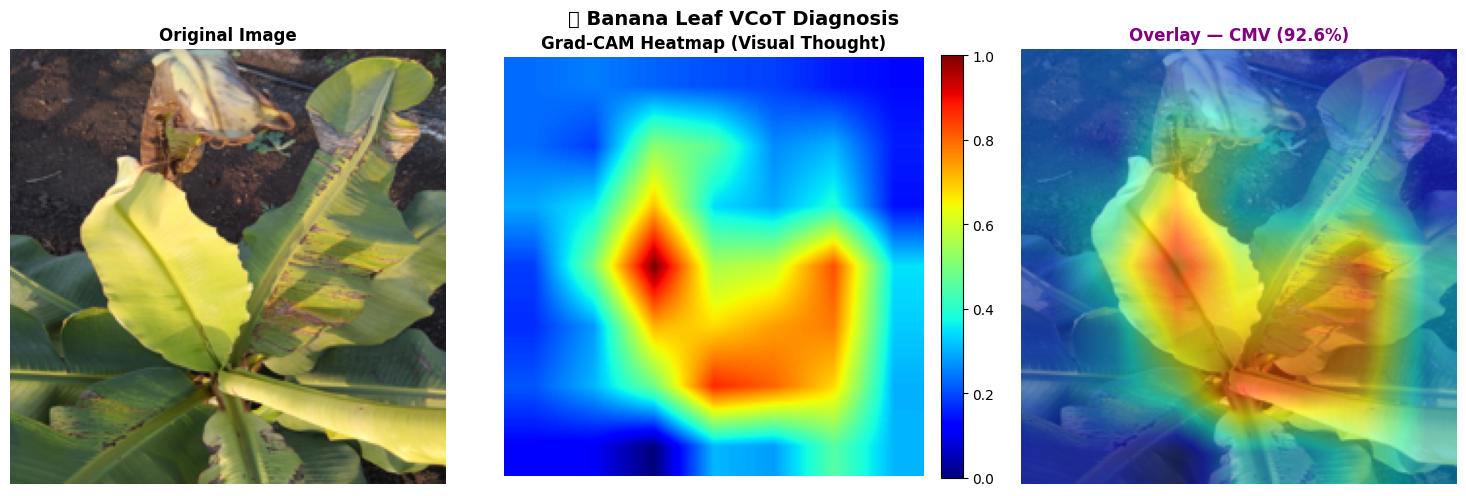

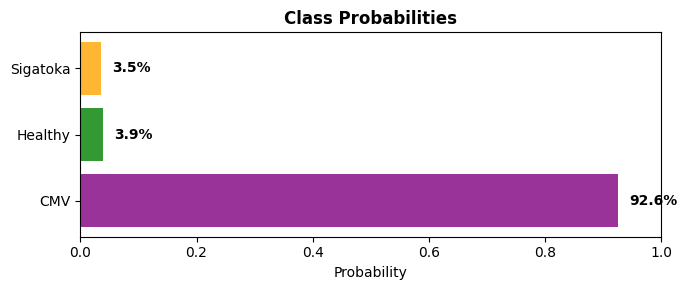

────────────────────────────────────────────────────────────────────────
  PREDICTED CLASS  : CMV
  CONFIDENCE       : 92.6%
  HEATMAP COVERAGE : 28.1%
  PEAK REGION      : lower-left
────────────────────────────────────────────────────────────────────────
  LLaVA OPEN-ENDED DESCRIPTION (Verbal Thought):

  The leaf displays a mosaic pattern with irregular light-green to
  yellow-green patches interspersed with darker green areas. The pattern
  is characterized by leaf distortion, chlorotic streaking along the
  midrib and veins, and possible leaf narrowing or rugosity. The
  attention of the classifier is focused on the lower-left quadrant of
  the leaf.
────────────────────────────────────────────────────────────────────────


In [26]:
# ── Run full VCoT inference on a test image ──────────────────────────────────
SAMPLE_IMAGE_PATH = '/content/sample_banana_leaf.jpg'   # ← EDIT THIS PATH if you have a custom image

# Auto-pick a test image if SAMPLE_IMAGE_PATH doesn't exist
if not os.path.exists(SAMPLE_IMAGE_PATH):
    test_imgs = list(Path(SPLIT_ROOT).rglob('test/**/*.jpg')) + \
                list(Path(SPLIT_ROOT).rglob('test/**/*.png'))
    if test_imgs:
        SAMPLE_IMAGE_PATH = str(random.choice(test_imgs))
        print(f'Auto-selected test image: {SAMPLE_IMAGE_PATH}')
    else:
        print('⚠️  No test image found. Upload an image and set SAMPLE_IMAGE_PATH.')

if os.path.exists(SAMPLE_IMAGE_PATH):
    result = diagnose_leaf(
        image_path  = SAMPLE_IMAGE_PATH,
        model       = best_model,
        gradcam_obj = gradcam,
        class_names = CLASS_NAMES,
        device      = DEVICE,
        use_llava   = True,
        save_dir    = '/content/banana_outputs/'
    )
    display_result(result, SAMPLE_IMAGE_PATH)

---
## Phase 8 — Evaluation & Analysis

Classifier metrics are evaluated over the **full** test set (no LLaVA — too slow for hundreds of generations). LLaVA description quality is evaluated qualitatively in Phase 9 on a curated batch.

In [27]:
# ── Full test set evaluation (classifier only — LLaVA skipped for speed) ─────
@torch.no_grad()
def full_evaluation(model, loader, class_names, device):
    '''Run model on entire test set and compute all metrics.'''
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in loader:
        images = images.to(device)
        logits = model(images)
        probs  = F.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    print('=' * 65)
    print('TEST SET EVALUATION (EfficientNet-B0 classifier — Banana)')
    print('=' * 65)
    print(classification_report(all_labels, all_preds,
                                 target_names=class_names,
                                 digits=4))

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


test_preds, test_labels, test_probs = full_evaluation(
    best_model, test_loader, CLASS_NAMES, DEVICE
)

TEST SET EVALUATION (EfficientNet-B0 classifier — Banana)
              precision    recall  f1-score   support

         CMV     1.0000    0.9937    0.9968       158
     Healthy     0.9930    1.0000    0.9965       142
    Sigatoka     1.0000    1.0000    1.0000       157

    accuracy                         0.9978       457
   macro avg     0.9977    0.9979    0.9978       457
weighted avg     0.9978    0.9978    0.9978       457



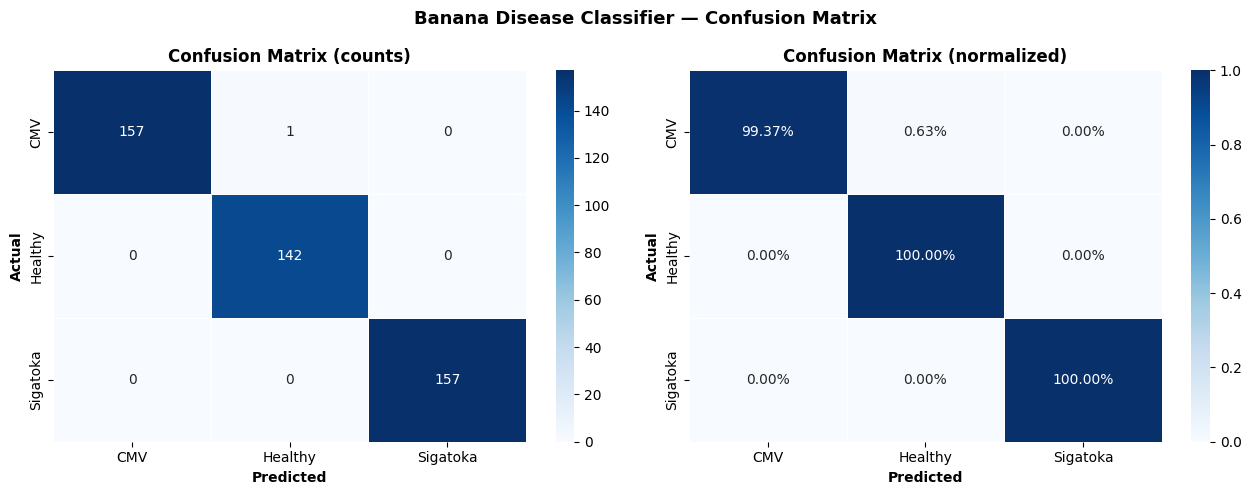

In [28]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
def plot_confusion_matrix(labels, preds, class_names):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2%'],
        ['Confusion Matrix (counts)', 'Confusion Matrix (normalized)']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    linewidths=0.5, ax=ax)
        ax.set_xlabel('Predicted', fontweight='bold')
        ax.set_ylabel('Actual', fontweight='bold')
        ax.set_title(title, fontweight='bold')

    plt.suptitle('Banana Disease Classifier — Confusion Matrix', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('/content/banana_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(test_labels, test_preds, CLASS_NAMES)

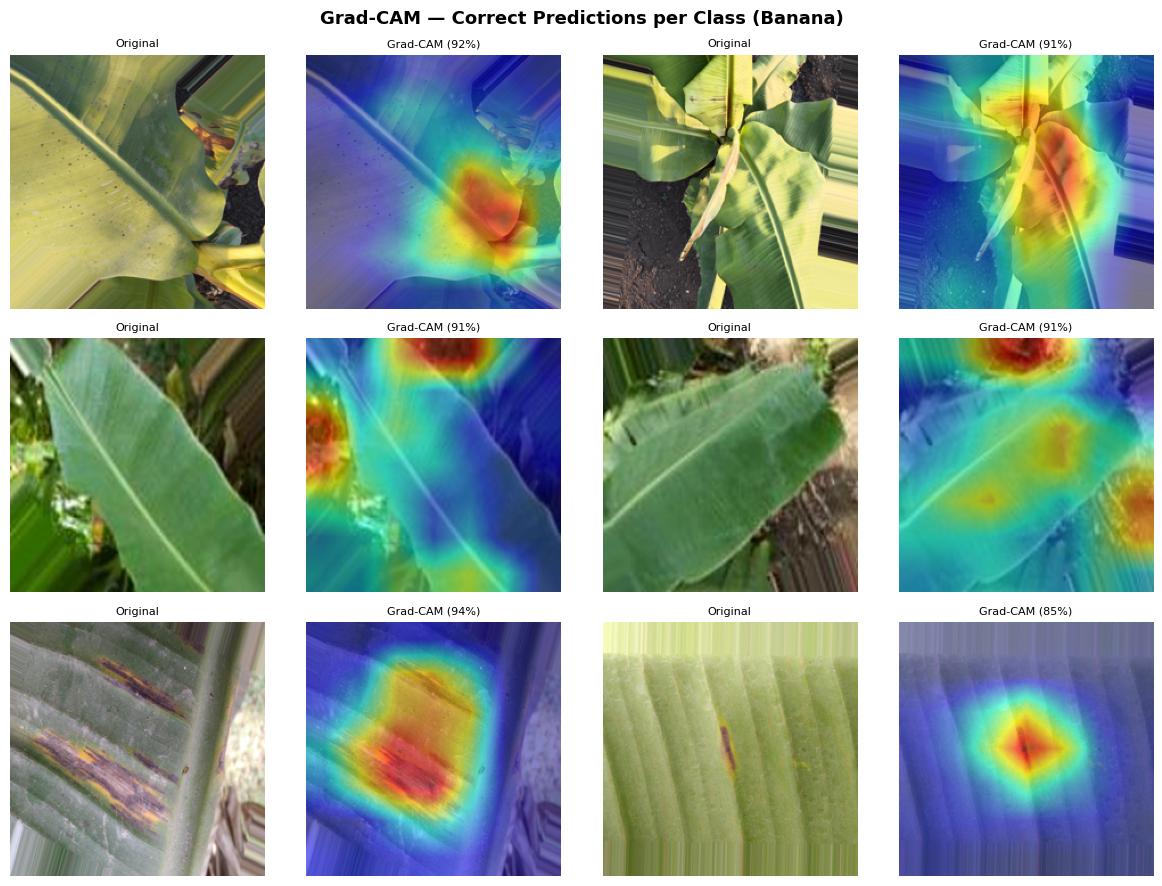

In [29]:
# ── Qualitative Grad-CAM Evaluation: correct predictions per class ───────────
# Checks whether Grad-CAM highlights the *right* regions per class.

def eval_gradcam_per_class(model, gradcam_obj, dataset, class_names, device, n=2):
    '''For each class, show n correctly classified examples with Grad-CAM.'''
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    model.eval()

    class_correct = {cls: [] for cls in class_names}

    for img_path, label in dataset.samples:
        cls = idx_to_class[label]
        if len(class_correct[cls]) >= n:
            continue

        rgb_float, tensor, _ = preprocess_image(img_path)
        with torch.no_grad():
            probs = F.softmax(model(tensor), dim=1)[0]
        pred_idx = probs.argmax().item()
        pred_cls = class_names[pred_idx]

        if pred_cls == cls:
            heatmap = compute_gradcam(gradcam_obj, tensor, pred_idx)
            overlay = overlay_heatmap(rgb_float, heatmap)
            class_correct[cls].append((img_path, overlay, probs[pred_idx].item(), heatmap))

        if all(len(v) >= n for v in class_correct.values()):
            break

    fig, axes = plt.subplots(len(class_names), n * 2,
                              figsize=(n * 2 * 3, len(class_names) * 3))

    for row, cls in enumerate(class_names):
        for col, (img_path, overlay, conf, heatmap) in enumerate(class_correct[cls]):
            pil = Image.open(img_path).resize((IMAGE_SIZE, IMAGE_SIZE))
            axes[row][col * 2].imshow(pil)
            axes[row][col * 2].axis('off')
            if col == 0:
                axes[row][col * 2].set_ylabel(cls, fontsize=10, fontweight='bold')
            axes[row][col * 2].set_title('Original', fontsize=8)
            axes[row][col * 2 + 1].imshow(overlay)
            axes[row][col * 2 + 1].axis('off')
            axes[row][col * 2 + 1].set_title(f'Grad-CAM ({conf:.0%})', fontsize=8)

    plt.suptitle('Grad-CAM — Correct Predictions per Class (Banana)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/banana_gradcam_per_class.png', dpi=150, bbox_inches='tight')
    plt.show()


eval_gradcam_per_class(best_model, gradcam, test_dataset, CLASS_NAMES, DEVICE, n=2)

In [30]:
# ── Hard-Case Benchmark ──────────────────────────────────────────────────────
# Classifier-only (no LLaVA) so we can evaluate many images quickly.

def assess_image_difficulty(img_path: str) -> dict:
    img = Image.open(img_path).convert('RGB').resize((128, 128))
    arr = np.array(img).astype(np.float32)

    brightness = arr.mean() / 255.0
    variance   = arr.std() / 255.0

    h, w = arr.shape[:2]
    center = arr[h//4:3*h//4, w//4:3*w//4]
    green_ratio = (center[:,:,1] > center[:,:,0]).mean()

    difficulty = 'normal'
    if brightness < 0.3:
        difficulty = 'low_light'
    elif variance > 0.25:
        difficulty = 'cluttered'
    elif green_ratio < 0.4:
        difficulty = 'partial_leaf'

    return {'brightness': brightness, 'variance': variance,
            'green_ratio': green_ratio, 'difficulty': difficulty}


@torch.no_grad()
def benchmark_hard_cases(model, dataset, class_names, device, max_images=200):
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    model.eval()

    results_by_difficulty = {}

    for img_path, label in dataset.samples[:max_images]:
        diff_info = assess_image_difficulty(img_path)
        diff_tag  = diff_info['difficulty']

        _, tensor, _ = preprocess_image(img_path)
        logits = model(tensor)
        pred   = logits.argmax(dim=1).item()
        correct = int(pred == label)

        if diff_tag not in results_by_difficulty:
            results_by_difficulty[diff_tag] = []
        results_by_difficulty[diff_tag].append(correct)

    print('\n── Hard-Case Benchmark (Banana) ─────────────────────')
    print(f'{"Category":20s} {"Count":>8} {"Accuracy":>10}')
    print('-' * 42)
    for tag, scores in sorted(results_by_difficulty.items()):
        acc = np.mean(scores)
        print(f'{tag:20s} {len(scores):>8d} {acc:>10.2%}')


benchmark_hard_cases(best_model, test_dataset, CLASS_NAMES, DEVICE)


── Hard-Case Benchmark (Banana) ─────────────────────
Category                Count   Accuracy
------------------------------------------
cluttered                  12    100.00%
low_light                   2    100.00%
normal                    164    100.00%
partial_leaf               22    100.00%


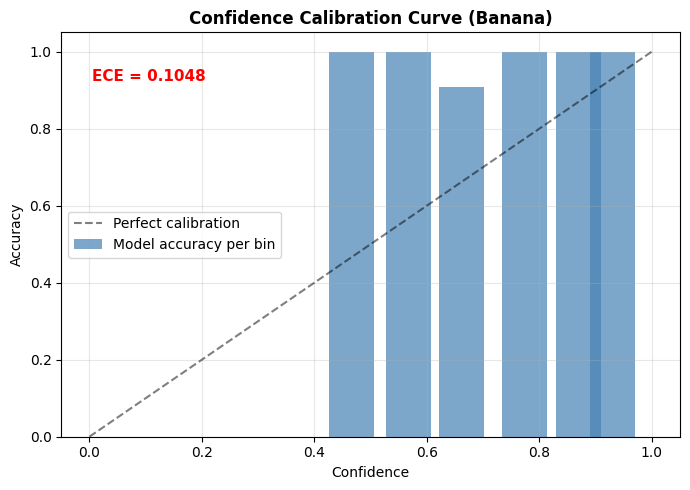


Expected Calibration Error (ECE): 0.1048
Lower ECE = better calibrated model (ideal: 0.0)


In [31]:
# ── Confidence Calibration Check ─────────────────────────────────────────────
def plot_confidence_calibration(labels, preds, probs, n_bins=10):
    max_probs = probs.max(axis=1)
    correct   = (preds == labels).astype(float)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_acc, bin_conf, bin_count = [], [], []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (max_probs >= lo) & (max_probs < hi)
        if mask.sum() == 0:
            continue
        bin_acc.append(correct[mask].mean())
        bin_conf.append(max_probs[mask].mean())
        bin_count.append(mask.sum())

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', alpha=0.5)
    ax.bar(bin_conf, bin_acc, width=0.08, alpha=0.7,
           color='steelblue', label='Model accuracy per bin')
    ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
    ax.set_title('Confidence Calibration Curve (Banana)', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)

    ece = np.sum([abs(acc - conf) * cnt
                  for acc, conf, cnt in zip(bin_acc, bin_conf, bin_count)]) / len(labels)
    ax.text(0.05, 0.88, f'ECE = {ece:.4f}', transform=ax.transAxes,
            fontsize=11, color='red', fontweight='bold')

    plt.tight_layout()
    plt.savefig('/content/banana_calibration.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nExpected Calibration Error (ECE): {ece:.4f}')
    print('Lower ECE = better calibrated model (ideal: 0.0)')


plot_confidence_calibration(test_labels, test_preds, test_probs)

---
## Phase 9 — Research Framing & Demo

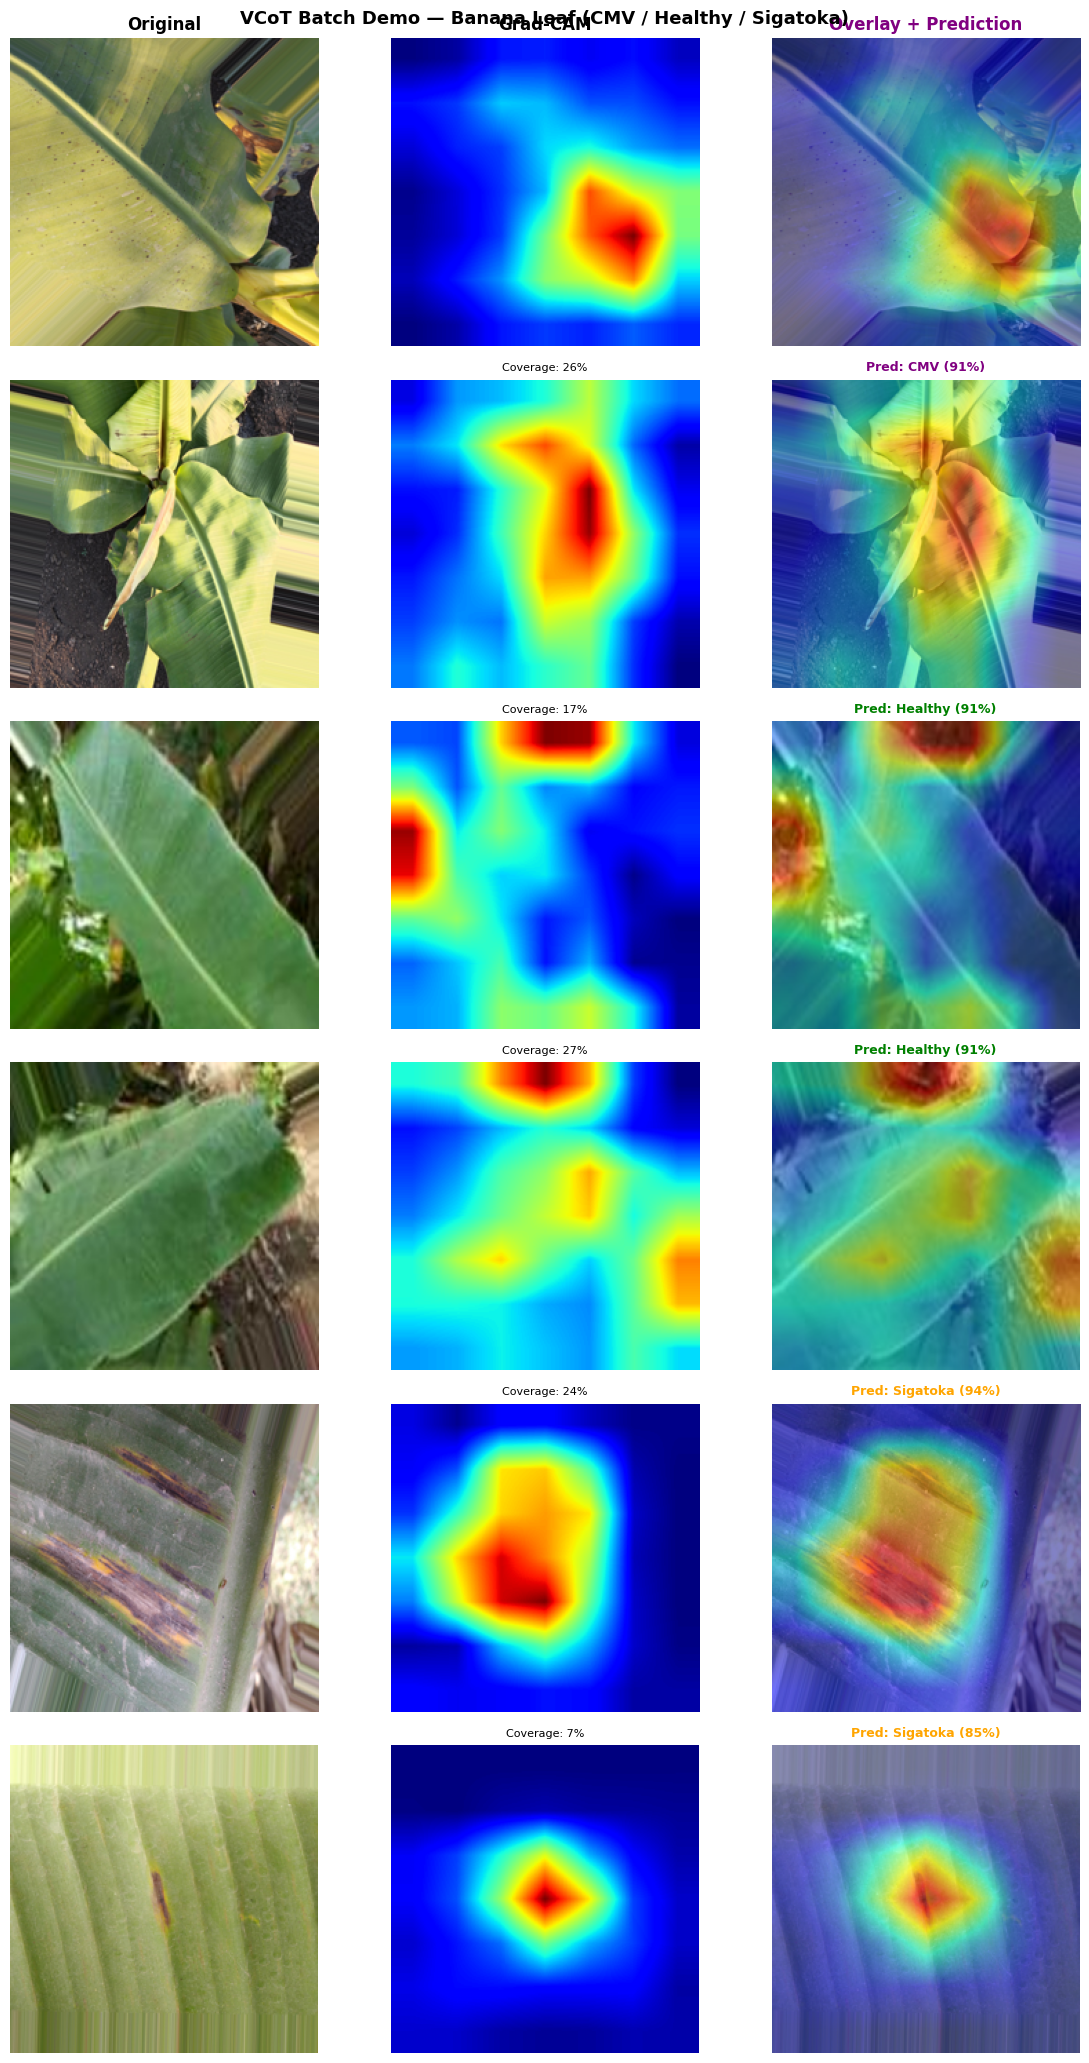


════════════════════════════════════════════════════════════════════════
  LLaVA OPEN-ENDED DESCRIPTIONS (Verbal Thoughts) — Banana
════════════════════════════════════════════════════════════════════════

  [cmv1009.jpg]
  True: CMV  |  Pred: CMV (92.2%)
  Description:
    The leaf exhibits a mosaic pattern with irregular light-green to
    yellow-green patches interspersed with darker green areas. The
    pattern is characterized by leaf distortion, chlorotic streaking
    along the midrib and veins, and possible leaf narrowing or rugosity.
    The attention of the classifier is focused on the lower-right
    quadrant of the leaf.

  [cmv1026.jpg]
  True: CMV  |  Pred: CMV (90.5%)
  Description:
    The leaf exhibits a mosaic pattern with irregular light-green to
    yellow-green patches interspersed with darker green areas. The
    pattern is accompanied by leaf distortion, chlorotic streaking along
    the midrib and veins, and possible leaf narrowing or rugosity.

  [CMV1.jpg]
  

In [32]:
# ── VCoT Batch Demo: full pipeline with LLaVA on 2 images per class ─────────
# This shows the complete visual+verbal thought chain for each class (CMV / Healthy / Sigatoka).
# LLaVA is slow (~3-5s per image on A100), so we keep this small.

def vcot_batch_demo(model, gradcam_obj, test_dataset, class_names, device,
                    n_per_class=2, save_dir='/content/banana_batch_demo/'):
    '''Run VCoT (classifier + Grad-CAM + LLaVA) on a few images per class.'''
    os.makedirs(save_dir, exist_ok=True)
    idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}

    samples_per_class = {cls: [] for cls in class_names}
    for img_path, label in test_dataset.samples:
        cls = idx_to_class[label]
        if len(samples_per_class[cls]) < n_per_class:
            samples_per_class[cls].append(img_path)

    selected = []
    for cls in class_names:
        selected.extend(samples_per_class[cls])

    # Grid: each row = 1 image → Original | Grad-CAM | Overlay
    fig, axes = plt.subplots(len(selected), 3,
                              figsize=(12, len(selected) * 3.5))
    if len(selected) == 1:
        axes = [axes]

    llava_descriptions = []

    for row, img_path in enumerate(selected):
        result = diagnose_leaf(
            img_path, model, gradcam_obj, class_names, device,
            use_llava=True, save_dir=save_dir
        )
        pil  = Image.open(img_path).resize((IMAGE_SIZE, IMAGE_SIZE))
        pred = result['predicted_class']
        conf = result['confidence']
        color = CLASS_COLORS[pred]
        true_lbl = Path(img_path).parent.name

        axes[row][0].imshow(pil); axes[row][0].axis('off')
        axes[row][0].set_ylabel(f'True: {true_lbl}', fontsize=8, rotation=90, labelpad=5)

        axes[row][1].imshow(result['heatmap'], cmap='jet', vmin=0, vmax=1)
        axes[row][1].axis('off')
        axes[row][1].set_title(f'Coverage: {result["heatmap_stats"]["coverage"]:.0%}',
                                fontsize=8)

        axes[row][2].imshow(result['overlay']); axes[row][2].axis('off')
        axes[row][2].set_title(f'Pred: {pred} ({conf:.0%})',
                                fontsize=9, color=color, fontweight='bold')

        llava_descriptions.append({
            'image': Path(img_path).name,
            'true':  true_lbl,
            'pred':  pred,
            'conf':  conf,
            'desc':  result['explanation'],
        })

    axes[0][0].set_title('Original',  fontweight='bold')
    axes[0][1].set_title('Grad-CAM',  fontweight='bold')
    axes[0][2].set_title('Overlay + Prediction', fontweight='bold')

    plt.suptitle('VCoT Batch Demo — Banana Leaf (CMV / Healthy / Sigatoka)',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(save_dir, 'banana_batch_demo_grid.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Print the LLaVA descriptions (verbal thoughts)
    import textwrap
    print('\n' + '═' * 72)
    print('  LLaVA OPEN-ENDED DESCRIPTIONS (Verbal Thoughts) — Banana')
    print('═' * 72)
    for item in llava_descriptions:
        print(f'\n  [{item["image"]}]')
        print(f'  True: {item["true"]}  |  Pred: {item["pred"]} ({item["conf"]:.1%})')
        print('  Description:')
        for line in textwrap.wrap(item['desc'], width=68):
            print(f'    {line}')
    print('\n' + '═' * 72)

    # Save descriptions to JSON
    with open(os.path.join(save_dir, 'banana_llava_descriptions.json'), 'w') as f:
        json.dump(llava_descriptions, f, indent=2)
    print(f'\n✅ Batch demo saved to {save_path}')
    print(f'✅ LLaVA descriptions saved to {save_dir}banana_llava_descriptions.json')


vcot_batch_demo(best_model, gradcam, test_dataset, CLASS_NAMES, DEVICE, n_per_class=2)

In [33]:
# ── Save final report to JSON ────────────────────────────────────────────────
final_report = {
    'timestamp':   datetime.now().strftime('%Y-%m-%d %H:%M'),
    'pipeline':    'VCoT (EfficientNet-B0 + Grad-CAM + LLaVA-1.5-7B) — Banana',
    'classifier':  'EfficientNet-B0',
    'vlm':         LLAVA_MODEL_ID,
    'dataset':     DATASET_ROOT,
    'classes':     CLASS_NAMES,
    'best_epoch':  best_epoch,
    'best_val_f1': round(best_val_f1, 4),
    'test_metrics': {
        'accuracy':        round(accuracy_score(test_labels, test_preds), 4),
        'macro_f1':        round(f1_score(test_labels, test_preds, average='macro'), 4),
        'macro_precision': round(precision_score(test_labels, test_preds,
                                                  average='macro', zero_division=0), 4),
        'macro_recall':    round(recall_score(test_labels, test_preds,
                                               average='macro', zero_division=0), 4),
    },
    'classifier_hyperparameters': {
        'image_size':       IMAGE_SIZE,
        'batch_size':       BATCH_SIZE,
        'epochs':           NUM_EPOCHS,
        'lr':               LR,
        'weight_decay':     WEIGHT_DECAY,
        'label_smoothing':  LABEL_SMOOTHING,
    },
    'llava_settings': {
        'model_id':         LLAVA_MODEL_ID,
        'dtype':            'bfloat16',
        'max_new_tokens':   LLAVA_MAX_NEW_TOKENS,
        'temperature':      LLAVA_TEMPERATURE,
        'do_sample':        LLAVA_DO_SAMPLE,
    },
}

with open('/content/banana_final_report.json', 'w') as f:
    json.dump(final_report, f, indent=2)

print('✅ Final report saved to /content/banana_final_report.json')
print(json.dumps(final_report, indent=2))

✅ Final report saved to /content/banana_final_report.json
{
  "timestamp": "2026-04-26 08:33",
  "pipeline": "VCoT (EfficientNet-B0 + Grad-CAM + LLaVA-1.5-7B) \u2014 Banana",
  "classifier": "EfficientNet-B0",
  "vlm": "llava-hf/llava-1.5-7b-hf",
  "dataset": "/content/drive/MyDrive/FINAL_DATASET_CROP_MONITORING",
  "classes": [
    "CMV",
    "Healthy",
    "Sigatoka"
  ],
  "best_epoch": 1,
  "best_val_f1": 1.0,
  "test_metrics": {
    "accuracy": 0.9978,
    "macro_f1": 0.9978,
    "macro_precision": 0.9977,
    "macro_recall": 0.9979
  },
  "classifier_hyperparameters": {
    "image_size": 224,
    "batch_size": 32,
    "epochs": 30,
    "lr": 0.0003,
    "weight_decay": 0.0001,
    "label_smoothing": 0.1
  },
  "llava_settings": {
    "model_id": "llava-hf/llava-1.5-7b-hf",
    "dtype": "bfloat16",
    "max_new_tokens": 140,
    "temperature": 0,
    "do_sample": false
  }
}


---
## Research Framing

### How to Describe This Project

**Title suggestion:**
*Visual Chain-of-Thought for Banana Leaf Disease Diagnosis: Grad-CAM Evidence Grounding with LLaVA-1.5-7B Open-Ended Descriptions*

---

### How This Differs from Plain Classification or Rule-Based Explanation

| Plain Classification | Rule-Based Explanation (V0) | **VCoT + LLaVA (This V1)** |
|---|---|---|
| Output: label only | Output: label + template text | Output: label + heatmap + open-ended LLaVA description |
| Black-box decision | Spatially grounded via heatmap | Spatially grounded + open-ended multimodal reasoning |
| No interpretability | Fixed templates per class | Free-form description, can flag mismatches |
| No failure signal | Confidence only | Confidence + LLaVA can verbalize mismatch between symptoms and predicted class |

---

### Connection to MVoT / VCoT

> *"Inspired by Multimodal Visualization-of-Thought (Li et al., 2025), which proposes that models should externalize reasoning through visual and verbal thoughts, this work implements a two-stage evidence-grounded chain for banana leaf disease diagnosis. The visual thought is produced by Grad-CAM on the last convolutional block of a fine-tuned EfficientNet-B0 classifier, yielding a spatial saliency map over the banana leaf. The verbal thought is then produced by LLaVA-1.5-7B's language head, conditioned on (1) the Grad-CAM overlay image as visual input and (2) a textual prompt containing the classifier's predicted class (CMV / Healthy / Sigatoka), confidence, and heatmap statistics. Unlike a rule-based template system, LLaVA generates free-form symptom descriptions that can handle ambiguous cases and verbalize mismatches between the visible symptoms and the predicted class."*

---

### Known Limitations
1. **Grad-CAM is post-hoc** — reflects classifier attention, not necessarily the medically correct region.
2. **LLaVA may hallucinate** — open-ended generation can invent symptoms on ambiguous images.
3. **LLaVA is zero-shot** — not fine-tuned on banana pathology data; responses can be generic.
4. **3 classes only** — real banana crops have additional threats (Panama disease, Bacterial wilt, Bunchy Top Virus, etc.).
5. **No quantitative evaluation of description quality** — qualitative assessment only in V1.
6. **Latency** — LLaVA adds ~3-5s per image on A100, unsuitable for real-time batch use.

### Suggested V2 Improvements
- **Fine-tune LLaVA with LoRA** on expert-written banana pathology descriptions.
- **Describe-then-predict loop**: feed LLaVA's description back into a text classifier to cross-check the CNN prediction.
- **Temperature scaling** on EfficientNet logits for better calibrated confidence.
- **Multi-crop LLaVA**: crop the high-activation region from the Grad-CAM peak for sharper, more local descriptions.
- **Extend to more classes** (Panama Disease, Bacterial Wilt, Bunchy Top, Anthracnose, etc.).

Upload a banana leaf image:


Saving Gemini_Generated_Image_ovltehovltehovlt.png to Gemini_Generated_Image_ovltehovltehovlt.png

Running VCoT diagnosis on: Gemini_Generated_Image_ovltehovltehovlt.png


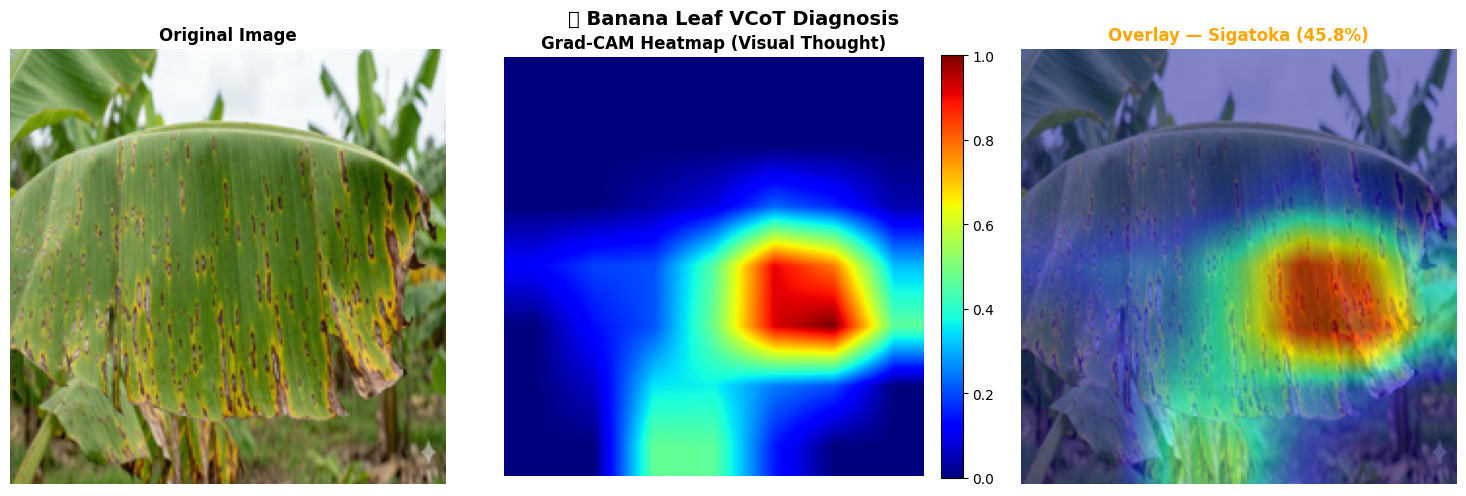

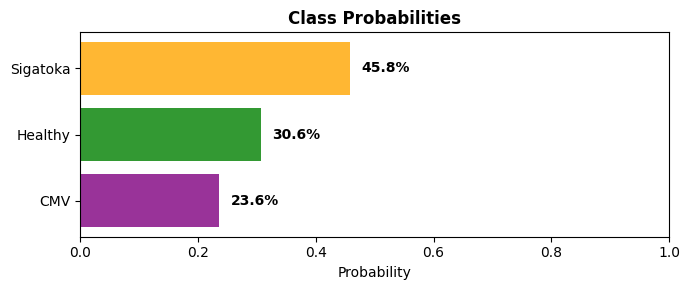

────────────────────────────────────────────────────────────────────────
  PREDICTED CLASS  : Sigatoka
  CONFIDENCE       : 45.8%
  HEATMAP COVERAGE : 10.4%
  PEAK REGION      : lower-right
────────────────────────────────────────────────────────────────────────
  LLaVA OPEN-ENDED DESCRIPTION (Verbal Thought):

  The leaf exhibits a mosaic texture with yellow and brown streaks that
  are parallel to the veins. The streaks are elongated and extend from
  the veins, eventually forming dark-brown to black necrotic lesions
  with yellowish halos. The attention of the classifier is focused on
  the lower-right quadrant of the leaf, which is the area with the most
  visible symptoms.
────────────────────────────────────────────────────────────────────────


In [34]:
# ── Quick Single-Image Upload Demo (for presentations) ───────────────────────
# Upload any banana leaf image to Colab and run this cell.

try:
    from google.colab import files
    print('Upload a banana leaf image:')
    uploaded = files.upload()

    if uploaded:
        uploaded_path = list(uploaded.keys())[0]
        print(f'\nRunning VCoT diagnosis on: {uploaded_path}')

        result = diagnose_leaf(
            image_path  = uploaded_path,
            model       = best_model,
            gradcam_obj = gradcam,
            class_names = CLASS_NAMES,
            device      = DEVICE,
            use_llava   = True,
            save_dir    = '/content/banana_uploads_output/'
        )
        display_result(result, uploaded_path)
except ImportError:
    print('ℹ️  Not in Colab — to run on a custom image, call:\n'
          '   result = diagnose_leaf("<path>", best_model, gradcam, CLASS_NAMES, DEVICE)\n'
          '   display_result(result, "<path>")')